In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score

In [8]:
df = pd.read_csv('/content/engineered_dataset.csv')
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,Day_of_Month,month,year,week_day,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load,0,1,1,2018,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load,0,1,1,2018,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load,0,1,1,2018,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load,1,1,1,2018,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load,1,1,1,2018,0,1.545117,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,2018-12-31 23:00:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load,23,31,12,2018,0,1.610306,0
35036,2018-12-31 23:15:00,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load,23,31,12,2018,0,1.414227,0
35037,2018-12-31 23:30:00,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load,23,31,12,2018,0,1.304881,0
35038,2018-12-31 23:45:00,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load,23,31,12,2018,0,1.286155,0


In [9]:
df = df.drop(columns=["date", "High_Load", "CO2(tCO2)"])

In [10]:
df = pd.get_dummies(df,columns=["Load_Type", "Day_of_week", "WeekStatus"],dtype=int)
df.head(5)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,hour,Day_of_Month,month,year,...,Load_Type_Medium_Load,Day_of_week_Friday,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,WeekStatus_Weekday,WeekStatus_Weekend
0,3.17,2.95,0.0,73.21,100.0,900,0,1,1,2018,...,0,0,1,0,0,0,0,0,1,0
1,4.00,4.46,0.0,66.77,100.0,1800,0,1,1,2018,...,0,0,1,0,0,0,0,0,1,0
2,3.24,3.28,0.0,70.28,100.0,2700,0,1,1,2018,...,0,0,1,0,0,0,0,0,1,0
3,3.31,3.56,0.0,68.09,100.0,3600,1,1,1,2018,...,0,0,1,0,0,0,0,0,1,0
4,3.82,4.50,0.0,64.72,100.0,4500,1,1,1,2018,...,0,0,1,0,0,0,0,0,1,0


In [11]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Power_Factor_Ratio    1
dtype: int64


In [31]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Series([], dtype: int64)


In [15]:
X = df.drop(columns=["Usage_kWh"])
y = df["Usage_kWh"]

nan_rows_indices = X[X.isnull().any(axis=1)].index
X = X.drop(nan_rows_indices)
y = y.drop(nan_rows_indices)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [17]:
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
y_pred = linear_model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
print("LINEAR MODEL METRICS:")
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

y_pred = ridge_model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
print("\nRIDGE MODEL METRICS:")
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

y_pred = decision_tree.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
print("\nDECISION TREE MODEL METRICS:")
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

y_pred = random_forest.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
print("\nRANDOM FOREST MODEL METRICS:")
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R2)

LINEAR MODEL METRICS:
MAE: 5.570743358941495
RMSE: 7.930026725490726
R²: 0.9437986402781404

RIDGE MODEL METRICS:
MAE: 5.563930490898996
RMSE: 7.930188903167393
R²: 0.9437963414966956

DECISION TREE MODEL METRICS:
MAE: 0.5190025684931507
RMSE: 1.2785471351602506
R²: 0.9985390646160007

RANDOM FOREST MODEL METRICS:
MAE: 0.26264656107305956
RMSE: 0.7518158907795912
R²: 0.9994948498074239


In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}
for name, model in models.items():
    rmse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse_scores = -rmse_scores

    print(f"{name}")
    print("RMSE for each fold:", rmse_scores)
    print("Mean RMSE:", rmse_scores.mean())
    print("\n" )

Linear Regression
RMSE for each fold: [7.8789638  7.93430699 7.74859263 7.77697089 7.92195434]
Mean RMSE: 7.8521577287995274


Ridge Regression
RMSE for each fold: [7.88019682 7.93374544 7.74739986 7.77794364 7.92251677]
Mean RMSE: 7.8523605045000595


Decision Tree
RMSE for each fold: [1.43798221 1.72686175 1.47733252 1.50317342 1.3586142 ]
Mean RMSE: 1.500792822286162


Random Forest
RMSE for each fold: [0.8725236  1.16445437 0.8219203  0.95309526 0.85859773]
Mean RMSE: 0.9341182530251249




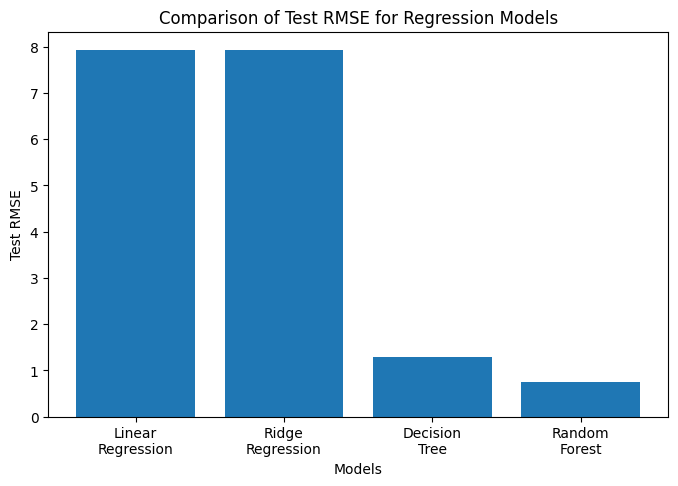

In [28]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_model.predict(X_test)))
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_model.predict(X_test)))
tree_rmse = np.sqrt(mean_squared_error(y_test, decision_tree.predict(X_test)))
forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest.predict(X_test)))

models = [
    "Linear\nRegression",
    "Ridge\nRegression",
    "Decision\nTree",
    "Random\nForest"
]
rmse_values = [linear_rmse, ridge_rmse, tree_rmse, forest_rmse]
plt.figure(figsize=(8, 5))
plt.bar(models, rmse_values)
plt.title("Comparison of Test RMSE for Regression Models")
plt.xlabel("Models")
plt.ylabel("Test RMSE")

plt.show()

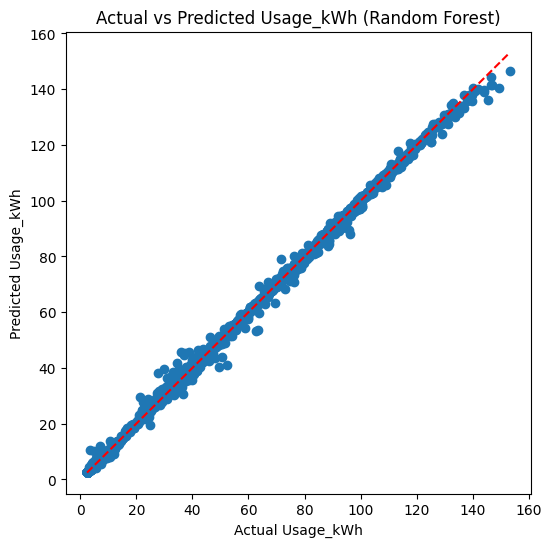

In [30]:
y_pred = random_forest.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title("Actual vs Predicted Usage_kWh (Random Forest)")

plt.show()